# Advanced Python

<img src="./img/2_python_what_next.png" width="500px">
<br><br>

In this session we will:
- cover some miscelleanous concepts
- introduce [NumPy](#first-steps-into-numpy)
- introduce [Pandas](#pandas)

that will make you a more productive Python programmer.
<br><br>

# Type annotations

Python is a dynamically typed language.

In [1]:
def add(a, b):
    return(a + b)

assert add(10, 5) == 15, "+ is valid for numbers"
assert add([1, 2], [3]) == [1, 2, 3], "+ is valid for lists"
assert add("hello ", "there") == "hello there", "+ is valid for strings"

In [2]:
# you cannot mix types

try:
    add(10, "five")
except TypeError as e:
    print(f"TypeError: {e}")

TypeError: unsupported operand type(s) for +: 'int' and 'str'


Statically typed languages like C, C++, Swift ... do not have this problem (but lack flexibility otherwise).

Python offers __type annotations__ to hint the correct typing.

In [3]:
# let's redefine add with type hints

def add(a: int, b:int) -> int:
    return(a + b)

<table>
<tr>
<td style="border-style: none"><img src="./img/0_students_input.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><h5>Students task:</h5>Try adding a cell above and below the new definition and enter "add(". See how the type hinting in the IDE changes.</td>
</tr>
</table>

In [4]:
# you still can feed any type to the function. But the IDE will hint you into the right direction.

add("hi", " there")                                     # can be done but the IDE hints otherwise

'hi there'

In [5]:
add(1, "five")                                          # still does not work

TypeError: unsupported operand type(s) for +: 'int' and 'str'

Typing does not prevent errors.

Typing provides readability.

In [6]:
# here are two function definitions that provide the same functionality

from typing import List
Vector = List[float]

def dot_product(x, y): ...

def dot_product(x: Vector, y: Vector) -> float: ...

# Which one is more readable?

If you want to check typing and get warnings, you may want to use [mypy](https://www.mypy-lang.org/).

In [7]:
from typing import Union

def secretly_ugly_function(value, operation): ...

def ugly_function(value: int, operation: Union[str, int, float, bool]) -> int:
    ...

Type annotation has the following benefits:

- write more readable code
- support IDE's type hinting and autocompletion
- discipline programmers to write cleaner code (well, give them tools to self-discipline)

Let's see some examples.

In [8]:
# nice try

from typing import List  # note capital L
def total(xs: list) -> float:
    return sum(xs)

# better

def total(xs: List[float]) -> float:
    return sum(xs)

In [9]:
# typing the obious is superfluous

# This is how to type-annotate variables when you define them.
# But this is unnecessary; it's "obvious" x is an int.
from typing import Optional
x: int = 5

# but what about this?
values = []                                             # what's my type?
best_so_far = None                                      # what's my type?

# this could be
values: List[int] = []
best_so_far: Optional[float] = None                     # allowed to be either a float or None

In [10]:
# the typing modules has plenty of types

from typing import Dict, Iterable, Tuple
lazy = True

# the type annotations in this snippet are all unnecessary

# keys are strings, values are ints
counts: Dict[str, int] = {'data': 1, 'science': 2}

# lists and generators are both iterable
if lazy:
    evens: Iterable[int] = (x for x in range(10) if x % 2 == 0)
else:
    evens = [0, 2, 4, 6, 8]

# tuples specify a type for each element
triple: Tuple[int, float, int] = (10, 2.3, 5)

In [11]:
# Pythons functions are first class objects. So they can be annotated as well

from typing import Callable

# The type hint says that repeater is a function that takes
# two arguments, a string and an int, and
# returns a string.

def twice(repeater: Callable[[str, int], str], s: str) -> str:
    return repeater(s, 2)

def comma_repeater(s: str, n: int) -> str:
    n_copies = [s for _ in range(n)]
    return ', '.join(n_copies)

assert twice(comma_repeater, "type hints") == "type hints, type hints"

In [12]:
# annotations are just another Python objects. We can assign them to variables for easy reference

Number = int
Numbers = List[Number]

def total(xs: Numbers) -> Number:
    return sum(xs)

total([1,2,3,4])

10

# First steps into NumPy

`NumPy` (numerical Python) is a collection of highly optimized and compute-efficient functions.

The following samples were taken from [NumPy: the absolute basics for beginners](https://numpy.org/doc/stable/user/absolute_beginners.html).

In [13]:
# import numpy

import numpy as np

In [14]:
# Numpy uses arrays as opposed to Pythons lists

a = np.array([1, 2, 3, 4, 5, 6])
a

array([1, 2, 3, 4, 5, 6])

### Create numpy arrays

In [15]:
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
a

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [16]:
print(a[0])                                                 # print 0th row (1st row that is)
print(a[1,2])                                               # address 1th row, 2nd element, 0-based

[1 2 3 4]
7


In [17]:
# arrays have shape

a.shape                                                     # rows, cols

(3, 4)

In [18]:
# b has two axes: 1st ... rows, length 2, 2nd ... cols, length 3

b = np.array([[0., 0., 0.],
     [1., 1., 1.]])
print(b)
b.shape

[[0. 0. 0.]
 [1. 1. 1.]]


(2, 3)

In [19]:
# array of zeros

np.zeros(3)

array([0., 0., 0.])

In [20]:
# identity array

np.ones((3, 2))

array([[1., 1.],
       [1., 1.],
       [1., 1.]])

In [21]:
np.empty(3)

array([0., 0., 0.])

In [22]:
# ranges

np.arange(4)

array([0, 1, 2, 3])

In [23]:
np.arange(2, 9, 2)                                      # start, end, stepsize

array([2, 4, 6, 8])

In [24]:
# this will be used often when plotting

np.linspace(0, 10, num=5)

array([ 0. ,  2.5,  5. ,  7.5, 10. ])

In [25]:
# initialize using value types

np.ones(2, dtype=np.int64)

array([1, 1])

In [26]:
# initializing arrays

np.ones((4, 3, 2))

array([[[1., 1.],
        [1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.],
        [1., 1.]]])

In [27]:
# generate random numbers

rng = np.random.default_rng()
rng.random(3)

array([0.99448569, 0.07712765, 0.24153223])

In [28]:
rng.random((3,2,4))

array([[[0.4543263 , 0.40737154, 0.92252027, 0.36929053],
        [0.82459484, 0.28527314, 0.50021008, 0.38755334]],

       [[0.38336662, 0.88898285, 0.6062704 , 0.65667534],
        [0.0609411 , 0.32252737, 0.69898173, 0.18249244]],

       [[0.62207366, 0.97897112, 0.10993192, 0.17950917],
        [0.2679418 , 0.87327368, 0.11772583, 0.64696853]]])

In [29]:
# generating integer randoms

rng.integers(5, size=(2, 4))

array([[3, 3, 1, 2],
       [0, 3, 2, 4]])

### Adding, removing, sorting arrays

In [30]:
arr = np.array([2, 1, 5, 3, 7, 4, 6, 8])
arr

array([2, 1, 5, 3, 7, 4, 6, 8])

In [31]:
np.sort(arr)

array([1, 2, 3, 4, 5, 6, 7, 8])

In [32]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])

np.concatenate((a, b))                                  # mind the brackets for the tuple

array([1, 2, 3, 4, 5, 6, 7, 8])

In [33]:
x = np.array([[1, 2], [3, 4]])
x

array([[1, 2],
       [3, 4]])

In [34]:
y = np.array([[5, 6]])
y

array([[5, 6]])

In [35]:
np.concatenate((x, y), axis=0)

array([[1, 2],
       [3, 4],
       [5, 6]])

In [36]:
np.concatenate((x, y), axis=1)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 2 and the array at index 1 has size 1

In [37]:
# but

z = np.array([[7], [8]])
z

array([[7],
       [8]])

In [38]:
np.concatenate((x, z), axis=1)

array([[1, 2, 7],
       [3, 4, 8]])

### Shape, size and resize

In [39]:
# create a 3D array

array_example = np.array([[[0, 1, 2, 3],
                           [4, 5, 6, 7]],
                          [[0, 1, 2, 3],
                           [4, 5, 6, 7]],
                          [[0, 1, 2, 3],
                           [4, 5, 6, 7]]])
array_example

array([[[0, 1, 2, 3],
        [4, 5, 6, 7]],

       [[0, 1, 2, 3],
        [4, 5, 6, 7]],

       [[0, 1, 2, 3],
        [4, 5, 6, 7]]])

In [40]:
array_example.ndim

3

In [41]:
array_example.size

24

In [42]:
array_example.shape

(3, 2, 4)

In [43]:
# reshape arrays

a = np.arange(6)
a

array([0, 1, 2, 3, 4, 5])

In [44]:
a.reshape(3, 2)

array([[0, 1],
       [2, 3],
       [4, 5]])

In [45]:
np.reshape(a, shape=(1, 6))

array([[0, 1, 2, 3, 4, 5]])

### Adding axes to arrays (extending arrays)

In [46]:
a = np.array([1, 2, 3, 4, 5, 6])
a.shape

(6,)

In [47]:
row_vector = a[np.newaxis, :]
row_vector.shape

(1, 6)

In [48]:
row_vector

array([[1, 2, 3, 4, 5, 6]])

In [49]:
col_vector = a[:, np.newaxis]
col_vector.shape


(6, 1)

In [50]:
col_vector


array([[1],
       [2],
       [3],
       [4],
       [5],
       [6]])

In [51]:
col_vector.reshape(6)

array([1, 2, 3, 4, 5, 6])

In [52]:
a

array([1, 2, 3, 4, 5, 6])

In [53]:
a.shape

(6,)

In [54]:
b = np.expand_dims(a, axis=1)
b.shape

(6, 1)

In [55]:
b

array([[1],
       [2],
       [3],
       [4],
       [5],
       [6]])

In [56]:
c = np.expand_dims(a, axis=0)
c.shape

(1, 6)

In [57]:
c

array([[1, 2, 3, 4, 5, 6]])

### Indexing and slicing

In [58]:
d = np.array([1, 2, 3])
d

array([1, 2, 3])

In [59]:
# indexing works like in lists in Python
d[0:2]

array([1, 2])

In [60]:
d[1:]

array([2, 3])

In [61]:
d[-2:]

array([2, 3])

In [62]:
data = np.array([[1, 2], [3, 4], [5, 6]])
data

array([[1, 2],
       [3, 4],
       [5, 6]])

In [63]:
data[0, 1]

np.int64(2)

In [64]:
data[1:3]

array([[3, 4],
       [5, 6]])

In [65]:
data[0:2, 0]

array([1, 3])

### Element selection

In [66]:
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
a

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [67]:
# select elements conforming to selection criteria

print(a[a < 7])

[1 2 3 4 5 6]


In [68]:
# selection criteria are first class objects

five_up = (a >= 5)
print(a[five_up])

[ 5  6  7  8  9 10 11 12]


In [69]:
divisible_by_2 = a[a % 2 == 0]
print(divisible_by_2)

[ 2  4  6  8 10 12]


In [70]:
# combine selections with & and, | or

c = a[(a > 2) & (a < 11)]
c

array([ 3,  4,  5,  6,  7,  8,  9, 10])

In [71]:
# selections are boolean masks

five_up = (a > 6) | (a == 5)
print(five_up)


[[False False False False]
 [ True False  True  True]
 [ True  True  True  True]]


### Stacking, splitting and element assignment

In [72]:
a = np.array([1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
arr1 = a[3:8]
arr1

array([4, 5, 6, 7, 8])

In [73]:
a1 = np.array([[1, 1],
               [2, 2]])

a2 = np.array([[3, 3],
               [4, 4]])

In [74]:
# vertical stack, mind dimensions

np.vstack((a1, a2))

array([[1, 1],
       [2, 2],
       [3, 3],
       [4, 4]])

In [75]:
# horizontal stack, mind dimensions

np.hstack((a1, a2))

array([[1, 1, 3, 3],
       [2, 2, 4, 4]])

In [76]:
x = np.arange(1, 25).reshape(2, 12)
x

array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]])

In [77]:
np.hsplit(x, 3)

[array([[ 1,  2,  3,  4],
        [13, 14, 15, 16]]),
 array([[ 5,  6,  7,  8],
        [17, 18, 19, 20]]),
 array([[ 9, 10, 11, 12],
        [21, 22, 23, 24]])]

In [78]:
np.vsplit(x, 2)

[array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]]),
 array([[13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]])]

In [79]:
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
a

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [80]:
b1 = a[0, :]
b1

array([1, 2, 3, 4])

In [81]:
b1[0] = 99
b1

array([99,  2,  3,  4])

In [82]:
a

array([[99,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [83]:
b2 = a.copy()
b2[0, 0] = 1
b2

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [84]:
a

array([[99,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

### Basic operations

In [85]:
data = np.array([1, 2])
data

array([1, 2])

In [86]:
ones = np.ones(2, dtype=int)
ones

array([1, 1])

In [87]:
data + ones

array([2, 3])

In [88]:
data - ones

array([0, 1])

In [89]:
data * data

array([1, 4])

In [90]:
data / data

array([1., 1.])

In [91]:
a = np.array([1, 2, 3, 4])
a.sum()

np.int64(10)

In [92]:
b = np.array([[1, 1], [2, 2]])
b.sum(axis=0)

array([3, 3])

In [93]:
b.sum(axis=1)

array([2, 4])

In [94]:
# broadcasting is a special operation that spreads the operation over the axis

data = np.array([1.0, 2.0, 3.0])
data * 1.6

array([1.6, 3.2, 4.8])

In [95]:
data.max()

np.float64(3.0)

In [96]:
data.min()

np.float64(1.0)

In [97]:
data.sum()

np.float64(6.0)

In [98]:
# the product of all elements

data.prod()

np.float64(6.0)

In [99]:
data.mean()

np.float64(2.0)

In [100]:
data.std()

np.float64(0.816496580927726)

In [101]:
a = np.array([[0.45053314, 0.17296777, 0.34376245, 0.5510652],
              [0.54627315, 0.05093587, 0.40067661, 0.55645993],
              [0.12697628, 0.82485143, 0.26590556, 0.56917101]])
a.min(axis=0)

array([0.12697628, 0.05093587, 0.26590556, 0.5510652 ])

In [102]:
a.min(axis=1)

array([0.17296777, 0.05093587, 0.12697628])

In [103]:
data = np.array([[1, 2], [5, 3], [4, 6]])
data

array([[1, 2],
       [5, 3],
       [4, 6]])

In [104]:
data.max(axis=0)

array([5, 6])

In [105]:
data.max(axis=1)

array([2, 5, 6])

### Unique item count

In [106]:
a = np.array([11, 11, 12, 13, 14, 15, 16, 17, 12, 13, 11, 14, 18, 19, 20])
np.unique(a)

array([11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

In [107]:
# can be done using collections.Counter

from collections import Counter
Counter(a).keys()

dict_keys([np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)])

In [108]:
# np.unique has several return types

v, i = np.unique(a, return_index=True)
v, i

(array([11, 12, 13, 14, 15, 16, 17, 18, 19, 20]),
 array([ 0,  2,  3,  4,  5,  6,  7, 12, 13, 14]))

In [109]:
np.unique(a, return_counts=True)

(array([11, 12, 13, 14, 15, 16, 17, 18, 19, 20]),
 array([3, 2, 2, 2, 1, 1, 1, 1, 1, 1]))

In [110]:
Counter(a)

Counter({np.int64(11): 3,
         np.int64(12): 2,
         np.int64(13): 2,
         np.int64(14): 2,
         np.int64(15): 1,
         np.int64(16): 1,
         np.int64(17): 1,
         np.int64(18): 1,
         np.int64(19): 1,
         np.int64(20): 1})

In [111]:
a_2d = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12], [1, 2, 3, 4]])
np.unique(a_2d, axis=0)

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

### Transposing, reshaping

In [112]:
data = np.arange(6)
data.reshape(2,3)

array([[0, 1, 2],
       [3, 4, 5]])

In [113]:
data.reshape(3,2)

array([[0, 1],
       [2, 3],
       [4, 5]])

In [114]:
data.reshape(6, 1)

array([[0],
       [1],
       [2],
       [3],
       [4],
       [5]])

In [115]:
data.reshape(2, 3)

array([[0, 1, 2],
       [3, 4, 5]])

In [116]:
data.reshape(2, 3).transpose()

array([[0, 3],
       [1, 4],
       [2, 5]])

In [117]:
# convenient abbreviation
data.reshape(2, 3).T

array([[0, 3],
       [1, 4],
       [2, 5]])

### Reversing arrays

In [118]:
data = np.arange(1, 9)
data

array([1, 2, 3, 4, 5, 6, 7, 8])

In [119]:
# reverse

np.flip(data)

array([8, 7, 6, 5, 4, 3, 2, 1])

In [120]:
data_2d = np.arange(1, 13).reshape(3, 4)
data_2d

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [121]:
# element wise reverse

np.flip(data_2d)

array([[12, 11, 10,  9],
       [ 8,  7,  6,  5],
       [ 4,  3,  2,  1]])

In [122]:
# row wise revers

np.flip(data_2d, axis=0)

array([[ 9, 10, 11, 12],
       [ 5,  6,  7,  8],
       [ 1,  2,  3,  4]])

In [123]:
# column wise reverse

np.flip(data_2d, axis=1)

array([[ 4,  3,  2,  1],
       [ 8,  7,  6,  5],
       [12, 11, 10,  9]])

In [124]:
# reversing specific rows and cols

data_2d[1] = np.flip(data_2d[1])                        # inline manipulation
data_2d

array([[ 1,  2,  3,  4],
       [ 8,  7,  6,  5],
       [ 9, 10, 11, 12]])

In [125]:
data_2d[:, 1] = np.flip(data_2d[:, 1])
data_2d

array([[ 1, 10,  3,  4],
       [ 8,  7,  6,  5],
       [ 9,  2, 11, 12]])

### Flatten n-dimensional arrays

In [126]:
a = np.arange(1, 13).reshape(3, 4)
a

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [127]:
a1 = a.flatten()                                        # copies a
a1[0] = 99
a1

array([99,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [128]:
a

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [129]:
a2 = a.ravel()                                          # ravel reshapes but maintains link to original
a2[0] = 98                                              # manipulates the parent array
a2

array([98,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [130]:
a

array([[98,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

### Getting information about objects and values

In [131]:
# use ? to get doc-strings in well-formatted manner
a?

Type:            ndarray
String form:    
[[98  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Length:          3
File:            ~/Development/py/ai/DS/DATE/.venv/lib/python3.14/site-packages/numpy/__init__.py
Docstring:      
ndarray(shape, dtype=None, buffer=None, offset=0, strides=None, order=None)
--

ndarray(shape, dtype=float, buffer=None, offset=0, strides=None, order=None)

An array object represents a multidimensional, homogeneous array
of fixed-size items.  An associated data-type object describes the
format of each element in the array (its byte-order, how many bytes it
occupies in memory, whether it is an integer, a floating point number,
or something else, etc.)

Arrays should be constructed using `array`, `zeros` or `empty` (refer
to the See Also section below).  The parameters given here refer to
a low-level method (`ndarray(...)`) for instantiating an array.

For more information, refer to the `numpy` module and examine the
methods and attributes of an array.

Parameters
---

In [132]:
a.__doc__

'ndarray(shape, dtype=None, buffer=None, offset=0, strides=None, order=None)\n--\n\nndarray(shape, dtype=float, buffer=None, offset=0, strides=None, order=None)\n\nAn array object represents a multidimensional, homogeneous array\nof fixed-size items.  An associated data-type object describes the\nformat of each element in the array (its byte-order, how many bytes it\noccupies in memory, whether it is an integer, a floating point number,\nor something else, etc.)\n\nArrays should be constructed using `array`, `zeros` or `empty` (refer\nto the See Also section below).  The parameters given here refer to\na low-level method (`ndarray(...)`) for instantiating an array.\n\nFor more information, refer to the `numpy` module and examine the\nmethods and attributes of an array.\n\nParameters\n----------\n(for the __new__ method; see Notes below)\n\nshape : tuple of ints\n    Shape of created array.\ndtype : data-type, optional\n    Any object that can be interpreted as a numpy data type.\n    D

In [133]:
print(a.__doc__)

ndarray(shape, dtype=None, buffer=None, offset=0, strides=None, order=None)
--

ndarray(shape, dtype=float, buffer=None, offset=0, strides=None, order=None)

An array object represents a multidimensional, homogeneous array
of fixed-size items.  An associated data-type object describes the
format of each element in the array (its byte-order, how many bytes it
occupies in memory, whether it is an integer, a floating point number,
or something else, etc.)

Arrays should be constructed using `array`, `zeros` or `empty` (refer
to the See Also section below).  The parameters given here refer to
a low-level method (`ndarray(...)`) for instantiating an array.

For more information, refer to the `numpy` module and examine the
methods and attributes of an array.

Parameters
----------
(for the __new__ method; see Notes below)

shape : tuple of ints
    Shape of created array.
dtype : data-type, optional
    Any object that can be interpreted as a numpy data type.
    Default is `numpy.float64`.


In [134]:
# get source code of callables using ??

def double(a: int) -> int:
    return a * 2

double??

Signature: double(a: int) -> int
Docstring: <no docstring>
Source:   
def double(a: int) -> int:
    return a * 2
File:      /var/folders/qv/xtc65g0j0t9d0jzh3hh_kt580000gn/T/ipykernel_15415/683670348.py
Type:      function

### Save and load NumPy objects

With pure Python you would use `pickle`. NumPy offers `save()` and `load()`.

In [135]:
# save numpy array into file

filename = "./data/2b_saved_numpy_array.npy"                           # extension .npy appended automatically

a = np.arange(1, 7)
np.save(filename, a)

In [136]:
!cat "./data/2b_saved_numpy_array.npy"


�NUMPY v {'descr': '<i8', 'fortran_order': False, 'shape': (6,), }                                                            
                                          

In [137]:
# read saved array

b = np.load(filename)
b

array([1, 2, 3, 4, 5, 6])

In [138]:
# save CSV

filename = "./data/2b_saved_numpy_array.csv"

np.savetxt(filename, a)
!cat "./data/2b_saved_numpy_array.csv"


1.000000000000000000e+00
2.000000000000000000e+00
3.000000000000000000e+00
4.000000000000000000e+00
5.000000000000000000e+00
6.000000000000000000e+00


In [139]:
# load CSV

b = np.loadtxt(filename)
b

array([1., 2., 3., 4., 5., 6.])

If you want to save integers instead of floats, you must use the `fmt` parameter for savetxt().

### A final note on NumPy

NumPy can directy interact with `pandas` dataframes and `matplotlib` when printing arrays.

In [140]:
# working with pandas dataframes

import pandas as pd

a = np.array([[-2.58289208,  0.43014843, -1.24082018, 1.59572603],
              [ 0.99027828, 1.17150989,  0.94125714, -0.14692469],
              [ 0.76989341,  0.81299683, -0.95068423, 0.11769564],
              [ 0.20484034,  0.34784527,  1.96979195, 0.51992837]])

df = pd.DataFrame(a)                                    # generate pandas dataframe from numpy array
df

,0,1,2,3
0,-2.582892,0.430148,-1.240820,1.595726
1,0.990278,1.171510,0.941257,-0.146925
2,0.769893,0.812997,-0.950684,0.117696
3,0.204840,0.347845,1.969792,0.519928


In [141]:
# from Python list

music = [['Billie Holiday', 'Jazz', 1300000, 27000000],
         ['Jimmie Hendrix', 'Rock', 2700000, 70000000],
         ['Miles Davis', 'Jazz', 1500000, 48000000],
         ['SIA', 'Pop', 2000000, 74000000]]

type(music)

list

In [142]:
# to pandas dataframe

df = pd.DataFrame(music)
df

,0,1,2,3
0,Billie Holiday,Jazz,1300000,27000000
1,Jimmie Hendrix,Rock,2700000,70000000
2,Miles Davis,Jazz,1500000,48000000
3,SIA,Pop,2000000,74000000


In [143]:
# to numpy array

a = df.to_numpy()
a

array([['Billie Holiday', 'Jazz', 1300000, 27000000],
       ['Jimmie Hendrix', 'Rock', 2700000, 70000000],
       ['Miles Davis', 'Jazz', 1500000, 48000000],
       ['SIA', 'Pop', 2000000, 74000000]], dtype=object)

In [144]:
type(a)

numpy.ndarray

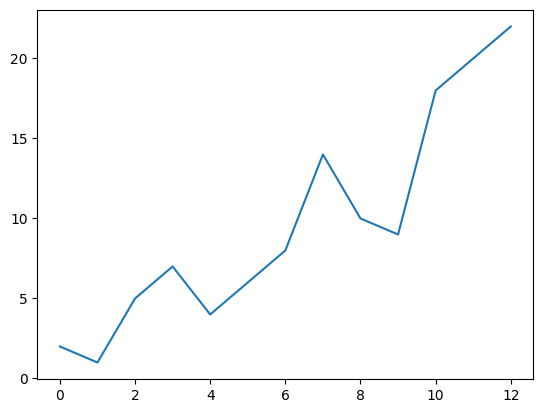

In [145]:
# working with matplotlib

import matplotlib.pyplot as plt

y = np.array([2, 1, 5, 7, 4, 6, 8, 14, 10, 9, 18, 20, 22])

plt.plot(y)
plt.show()

<table>
<tr>
<td style="border-style: none"><img src="./img/0_reference.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><u>Further reading:</u>
<ul>
<li><a href="https://numpy.org/doc/stable/user/quickstart.html">NumPy quick start</a></li>
<li><a href="https://numpy.org/doc/stable/user/absolute_beginners.html">NumPy: the absolute basics for beginners</a></li>
<li><a href="https://numpy.org/numpy-tutorials/features.html">NumPy tutorials</a></li>
</ul>
</td>
</tr>
</table>

<span style="font-size: 128px">&#9749;</span> Coffee break!

# Pandas

`Pandas` provides data structure handling to Python.

This tutorial is inspired by: [10 minutes to pandas](https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html)

In [146]:
import numpy as np
import pandas as pd

### Data series
https://pandas.pydata.org/docs/user_guide/dsintro.html#basic-data-structures-in-pandas

In [147]:
# create a simple data series (1-dimensional array)

s = pd.Series([1, 3, 5, np.nan, 6, 8])
s

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

In [148]:
dates = pd.date_range('20210101', periods=6)
dates

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
               '2021-01-05', '2021-01-06'],
              dtype='datetime64[us]', freq='D')

### Data frames
https://pandas.pydata.org/docs/user_guide/dsintro.html#object-creation

In [149]:
df = pd.DataFrame(np.random.randn(6,4), index=dates, columns=list('abcd'))
df

,a,b,c,d
2021-01-01,0.068290,1.823168,-0.108270,1.220329
2021-01-02,3.122622,-1.601458,1.196643,0.817082
2021-01-03,-1.108512,0.561038,1.014141,0.161506
2021-01-04,-1.641918,0.832497,0.110694,-0.336476
2021-01-05,0.106633,0.713491,-0.564858,-1.521280
2021-01-06,-0.673366,-1.012491,-1.829621,1.186874


In [150]:
df2 = pd.DataFrame({
    'A': 1.0,
    'B': pd.Timestamp('20210101'),
    'C': pd.Series(1, index=list(range(4)), dtype='float64'),
    'D': np.array([3]*4, dtype='int64'),
    'E': pd.Categorical(['test', 'train', 'test', 'train']),
    'F': 'foo'
})
df2

,A,B,C,D,E,F
0,1.0,2021-01-01,1.0,3,test,foo
1,1.0,2021-01-01,1.0,3,train,foo
2,1.0,2021-01-01,1.0,3,test,foo
3,1.0,2021-01-01,1.0,3,train,foo


In [151]:
df2.dtypes

A           float64
B    datetime64[us]
C           float64
D             int64
E          category
F               str
dtype: object

### Viewing data
https://pandas.pydata.org/docs/user_guide/basics.html#viewing-data

In [152]:
df.head()

,a,b,c,d
2021-01-01,0.068290,1.823168,-0.108270,1.220329
2021-01-02,3.122622,-1.601458,1.196643,0.817082
2021-01-03,-1.108512,0.561038,1.014141,0.161506
2021-01-04,-1.641918,0.832497,0.110694,-0.336476
2021-01-05,0.106633,0.713491,-0.564858,-1.521280


In [153]:
df.tail(3)

,a,b,c,d
2021-01-04,-1.641918,0.832497,0.110694,-0.336476
2021-01-05,0.106633,0.713491,-0.564858,-1.521280
2021-01-06,-0.673366,-1.012491,-1.829621,1.186874


In [154]:
df.index

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
               '2021-01-05', '2021-01-06'],
              dtype='datetime64[us]', freq='D')

In [155]:
df.columns

Index(['a', 'b', 'c', 'd'], dtype='str')

In [156]:
df.to_numpy()

array([[ 0.06829045,  1.82316764, -0.10827038,  1.22032887],
       [ 3.12262196, -1.60145797,  1.19664299,  0.81708155],
       [-1.10851153,  0.5610384 ,  1.01414099,  0.16150624],
       [-1.64191767,  0.83249678,  0.11069352, -0.3364761 ],
       [ 0.10663269,  0.71349138, -0.56485825, -1.52128013],
       [-0.67336629, -1.01249116, -1.8296213 ,  1.18687431]])

In [157]:
# this is rather expensive due to multiple dtypes and inherent casts
df2.to_numpy()

array([[1.0, Timestamp('2021-01-01 00:00:00'), 1.0, 3, 'test', 'foo'],
       [1.0, Timestamp('2021-01-01 00:00:00'), 1.0, 3, 'train', 'foo'],
       [1.0, Timestamp('2021-01-01 00:00:00'), 1.0, 3, 'test', 'foo'],
       [1.0, Timestamp('2021-01-01 00:00:00'), 1.0, 3, 'train', 'foo']],
      dtype=object)

### Magic 8

`Magic 8` (sometimes referred to as _Magic 7_) denotes a statistic overview over a data set.

In [158]:
# Magic 8, statistic evaluation
df.describe()

,a,b,c,d
count,6.000000,6.000000,6.000000,6.000000
mean,-0.021042,0.219374,-0.030212,0.254672
std,1.681800,1.276078,1.108649,1.061126
min,-1.641918,-1.601458,-1.829621,-1.521280
25%,-0.999725,-0.619109,-0.450711,-0.211981
50%,-0.302538,0.637265,0.001212,0.489294
75%,0.097047,0.802745,0.788279,1.094426
max,3.122622,1.823168,1.196643,1.220329


In [159]:
# a common function in machine learning and data science, transposing a dataframe

df.T

,2021-01-01,2021-01-02,2021-01-03,2021-01-04,2021-01-05,2021-01-06
a,0.068290,3.122622,-1.108512,-1.641918,0.106633,-0.673366
b,1.823168,-1.601458,0.561038,0.832497,0.713491,-1.012491
c,-0.108270,1.196643,1.014141,0.110694,-0.564858,-1.829621
d,1.220329,0.817082,0.161506,-0.336476,-1.521280,1.186874


In [160]:
df.sort_index(axis=1, ascending=False)

,d,c,b,a
2021-01-01,1.220329,-0.108270,1.823168,0.068290
2021-01-02,0.817082,1.196643,-1.601458,3.122622
2021-01-03,0.161506,1.014141,0.561038,-1.108512
2021-01-04,-0.336476,0.110694,0.832497,-1.641918
2021-01-05,-1.521280,-0.564858,0.713491,0.106633
2021-01-06,1.186874,-1.829621,-1.012491,-0.673366


In [161]:
df.sort_index(axis=0, ascending=False)

,a,b,c,d
2021-01-06,-0.673366,-1.012491,-1.829621,1.186874
2021-01-05,0.106633,0.713491,-0.564858,-1.521280
2021-01-04,-1.641918,0.832497,0.110694,-0.336476
2021-01-03,-1.108512,0.561038,1.014141,0.161506
2021-01-02,3.122622,-1.601458,1.196643,0.817082
2021-01-01,0.068290,1.823168,-0.108270,1.220329


In [162]:
df.sort_values(by='b')

,a,b,c,d
2021-01-02,3.122622,-1.601458,1.196643,0.817082
2021-01-06,-0.673366,-1.012491,-1.829621,1.186874
2021-01-03,-1.108512,0.561038,1.014141,0.161506
2021-01-05,0.106633,0.713491,-0.564858,-1.521280
2021-01-04,-1.641918,0.832497,0.110694,-0.336476
2021-01-01,0.068290,1.823168,-0.108270,1.220329


In [163]:
df.sort_values(by=['b','c'])

,a,b,c,d
2021-01-02,3.122622,-1.601458,1.196643,0.817082
2021-01-06,-0.673366,-1.012491,-1.829621,1.186874
2021-01-03,-1.108512,0.561038,1.014141,0.161506
2021-01-05,0.106633,0.713491,-0.564858,-1.521280
2021-01-04,-1.641918,0.832497,0.110694,-0.336476
2021-01-01,0.068290,1.823168,-0.108270,1.220329


### Data selection
#### with array references
https://pandas.pydata.org/docs/user_guide/indexing.html<br>
https://pandas.pydata.org/docs/user_guide/indexing.html#indexing-label

In [164]:
df['a']

2021-01-01    0.068290
2021-01-02    3.122622
2021-01-03   -1.108512
2021-01-04   -1.641918
2021-01-05    0.106633
2021-01-06   -0.673366
Freq: D, Name: a, dtype: float64

In [165]:
# if column name conforms to variable name
df.a

2021-01-01    0.068290
2021-01-02    3.122622
2021-01-03   -1.108512
2021-01-04   -1.641918
2021-01-05    0.106633
2021-01-06   -0.673366
Freq: D, Name: a, dtype: float64

In [166]:
df[['b', 'a']]

,b,a
2021-01-01,1.823168,0.068290
2021-01-02,-1.601458,3.122622
2021-01-03,0.561038,-1.108512
2021-01-04,0.832497,-1.641918
2021-01-05,0.713491,0.106633
2021-01-06,-1.012491,-0.673366


In [167]:
df[0:3]

,a,b,c,d
2021-01-01,0.068290,1.823168,-0.108270,1.220329
2021-01-02,3.122622,-1.601458,1.196643,0.817082
2021-01-03,-1.108512,0.561038,1.014141,0.161506


In [168]:
df[['a', 'c']][1:4]

,a,c
2021-01-02,3.122622,1.196643
2021-01-03,-1.108512,1.014141
2021-01-04,-1.641918,0.110694


In [169]:
col_list = ['b', 'd']
df[col_list][0:3]

,b,d
2021-01-01,1.823168,1.220329
2021-01-02,-1.601458,0.817082
2021-01-03,0.561038,0.161506


In [170]:
# rows are selected using slicing, cols via header list
df[0:3][col_list]

,b,d
2021-01-01,1.823168,1.220329
2021-01-02,-1.601458,0.817082
2021-01-03,0.561038,0.161506


In [171]:
df['20210102':'20210104']

,a,b,c,d
2021-01-02,3.122622,-1.601458,1.196643,0.817082
2021-01-03,-1.108512,0.561038,1.014141,0.161506
2021-01-04,-1.641918,0.832497,0.110694,-0.336476


In [172]:
df[['a', 'c']]['20210102':'20210104']

,a,c
2021-01-02,3.122622,1.196643
2021-01-03,-1.108512,1.014141
2021-01-04,-1.641918,0.110694


In [173]:
# exchanging index and column selection is possible
df['20210102':'20210104'][['a', 'c']]

,a,c
2021-01-02,3.122622,1.196643
2021-01-03,-1.108512,1.014141
2021-01-04,-1.641918,0.110694


### Selection 
#### positional addressing (loc, iloc, at, iat)
https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html#selection<br>
https://pandas.pydata.org/docs/user_guide/indexing.html#selection-by-label<br>
https://pandas.pydata.org/docs/user_guide/10min.html#selection-by-position

In [174]:
# use .at, .iat, .loc and .iloc for performance
# select row 0
df.loc[dates[0]]

a    0.068290
b    1.823168
c   -0.108270
d    1.220329
Name: 2021-01-01 00:00:00, dtype: float64

In [175]:
# selecting all rows for specific columns
df.loc[:, ['a', 'c']]

,a,c
2021-01-01,0.068290,-0.108270
2021-01-02,3.122622,1.196643
2021-01-03,-1.108512,1.014141
2021-01-04,-1.641918,0.110694
2021-01-05,0.106633,-0.564858
2021-01-06,-0.673366,-1.829621


In [176]:
# label slicing
df.loc['20200101':'20200104', ['a', 'c']]

,a,c


In [177]:
# iloc if addressing via integer index
df.iloc[0]

a    0.068290
b    1.823168
c   -0.108270
d    1.220329
Name: 2021-01-01 00:00:00, dtype: float64

In [178]:
df.loc[dates[0:1]]

,a,b,c,d
2021-01-01,0.06829,1.823168,-0.10827,1.220329


In [179]:
df.iloc[0:1]

,a,b,c,d
2021-01-01,0.06829,1.823168,-0.10827,1.220329


In [180]:
df.loc[:,['a', 'b']]

,a,b
2021-01-01,0.068290,1.823168
2021-01-02,3.122622,-1.601458
2021-01-03,-1.108512,0.561038
2021-01-04,-1.641918,0.832497
2021-01-05,0.106633,0.713491
2021-01-06,-0.673366,-1.012491


In [181]:
df.iloc[:, 1:3]

,b,c
2021-01-01,1.823168,-0.108270
2021-01-02,-1.601458,1.196643
2021-01-03,0.561038,1.014141
2021-01-04,0.832497,0.110694
2021-01-05,0.713491,-0.564858
2021-01-06,-1.012491,-1.829621


In [182]:
df.loc['20210102':'20210105', ['c', 'd']]

,c,d
2021-01-02,1.196643,0.817082
2021-01-03,1.014141,0.161506
2021-01-04,0.110694,-0.336476
2021-01-05,-0.564858,-1.521280


In [183]:
df.loc['20210106', ['a', 'b', 'c']]

a   -0.673366
b   -1.012491
c   -1.829621
Name: 2021-01-06 00:00:00, dtype: float64

In [184]:
# get scalar value
df.loc[dates[0], 'a']

np.float64(0.06829044789169032)

In [185]:
df.at[dates[0], 'a']

np.float64(0.06829044789169032)

In [186]:
df.loc[dates[0]]

a    0.068290
b    1.823168
c   -0.108270
d    1.220329
Name: 2021-01-01 00:00:00, dtype: float64

In [187]:
df.iloc[0, 0]

np.float64(0.06829044789169032)

In [188]:
# select by position
df.iloc[0]

a    0.068290
b    1.823168
c   -0.108270
d    1.220329
Name: 2021-01-01 00:00:00, dtype: float64

In [189]:
df.iloc[0][1:3]

b    1.823168
c   -0.108270
Name: 2021-01-01 00:00:00, dtype: float64

In [190]:
df.iloc[2:5, 2:4]

,c,d
2021-01-03,1.014141,0.161506
2021-01-04,0.110694,-0.336476
2021-01-05,-0.564858,-1.521280


In [191]:
df.iloc[[0, 2, 4],[0,2]]

,a,c
2021-01-01,0.068290,-0.108270
2021-01-03,-1.108512,1.014141
2021-01-05,0.106633,-0.564858


In [192]:
df.iloc[1:3,:]

,a,b,c,d
2021-01-02,3.122622,-1.601458,1.196643,0.817082
2021-01-03,-1.108512,0.561038,1.014141,0.161506


In [193]:
df.iloc[:, 1:3]

,b,c
2021-01-01,1.823168,-0.108270
2021-01-02,-1.601458,1.196643
2021-01-03,0.561038,1.014141
2021-01-04,0.832497,0.110694
2021-01-05,0.713491,-0.564858
2021-01-06,-1.012491,-1.829621


In [194]:
df.iloc[1,1]

np.float64(-1.601457972595411)

In [195]:
# same as above
df.iat[1,1]

np.float64(-1.601457972595411)

### Boolean conditions
https://pandas.pydata.org/docs/user_guide/indexing.html#boolean-indexing

In [196]:
df[df.a > 0]

,a,b,c,d
2021-01-01,0.068290,1.823168,-0.108270,1.220329
2021-01-02,3.122622,-1.601458,1.196643,0.817082
2021-01-05,0.106633,0.713491,-0.564858,-1.521280


In [197]:
df3 = df.copy()
df3['e'] = ['one', 'one', 'two', 'three', 'four', 'three']
df3

,a,b,c,d,e
2021-01-01,0.068290,1.823168,-0.108270,1.220329,one
2021-01-02,3.122622,-1.601458,1.196643,0.817082,one
2021-01-03,-1.108512,0.561038,1.014141,0.161506,two
2021-01-04,-1.641918,0.832497,0.110694,-0.336476,three
2021-01-05,0.106633,0.713491,-0.564858,-1.521280,four
2021-01-06,-0.673366,-1.012491,-1.829621,1.186874,three


In [198]:
df3[df3['e'].isin(['one', 'three'])]                    # as: "is in"

,a,b,c,d,e
2021-01-01,0.068290,1.823168,-0.108270,1.220329,one
2021-01-02,3.122622,-1.601458,1.196643,0.817082,one
2021-01-04,-1.641918,0.832497,0.110694,-0.336476,three
2021-01-06,-0.673366,-1.012491,-1.829621,1.186874,three


In [199]:
df3.d.to_list()

[1.2203288708048527,
 0.8170815456024869,
 0.16150623951420176,
 -0.3364760998794461,
 -1.5212801278904549,
 1.1868743137433038]

In [200]:
df3['s']=df3.d.to_list()
df3

,a,b,c,d,e,s
2021-01-01,0.068290,1.823168,-0.108270,1.220329,one,1.220329
2021-01-02,3.122622,-1.601458,1.196643,0.817082,one,0.817082
2021-01-03,-1.108512,0.561038,1.014141,0.161506,two,0.161506
2021-01-04,-1.641918,0.832497,0.110694,-0.336476,three,-0.336476
2021-01-05,0.106633,0.713491,-0.564858,-1.521280,four,-1.521280
2021-01-06,-0.673366,-1.012491,-1.829621,1.186874,three,1.186874


In [201]:
df3.where(df3.s.isna())

,a,b,c,d,e,s
2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,NaN,NaN,NaN,NaN,NaN,NaN


### Setting values

In [202]:
s2 = pd.Series([1, 2, 3, 4, 5, 6], index=pd.date_range('20210102', periods=6))
s2

2021-01-02    1
2021-01-03    2
2021-01-04    3
2021-01-05    4
2021-01-06    5
2021-01-07    6
Freq: D, dtype: int64

In [203]:
df['f'] = s2
df

,a,b,c,d,f
2021-01-01,0.068290,1.823168,-0.108270,1.220329,NaN
2021-01-02,3.122622,-1.601458,1.196643,0.817082,1.0
2021-01-03,-1.108512,0.561038,1.014141,0.161506,2.0
2021-01-04,-1.641918,0.832497,0.110694,-0.336476,3.0
2021-01-05,0.106633,0.713491,-0.564858,-1.521280,4.0
2021-01-06,-0.673366,-1.012491,-1.829621,1.186874,5.0


In [204]:
df.at[dates[0], 'f'] = 0
df

,a,b,c,d,f
2021-01-01,0.068290,1.823168,-0.108270,1.220329,0.0
2021-01-02,3.122622,-1.601458,1.196643,0.817082,1.0
2021-01-03,-1.108512,0.561038,1.014141,0.161506,2.0
2021-01-04,-1.641918,0.832497,0.110694,-0.336476,3.0
2021-01-05,0.106633,0.713491,-0.564858,-1.521280,4.0
2021-01-06,-0.673366,-1.012491,-1.829621,1.186874,5.0


In [205]:
df.iat[0,4] = -1.0
df

,a,b,c,d,f
2021-01-01,0.068290,1.823168,-0.108270,1.220329,-1.0
2021-01-02,3.122622,-1.601458,1.196643,0.817082,1.0
2021-01-03,-1.108512,0.561038,1.014141,0.161506,2.0
2021-01-04,-1.641918,0.832497,0.110694,-0.336476,3.0
2021-01-05,0.106633,0.713491,-0.564858,-1.521280,4.0
2021-01-06,-0.673366,-1.012491,-1.829621,1.186874,5.0


In [206]:
df.loc[:, 'd'] = np.array([5] * len(df))
df

,a,b,c,d,f
2021-01-01,0.068290,1.823168,-0.108270,5.0,-1.0
2021-01-02,3.122622,-1.601458,1.196643,5.0,1.0
2021-01-03,-1.108512,0.561038,1.014141,5.0,2.0
2021-01-04,-1.641918,0.832497,0.110694,5.0,3.0
2021-01-05,0.106633,0.713491,-0.564858,5.0,4.0
2021-01-06,-0.673366,-1.012491,-1.829621,5.0,5.0


In [207]:
df.dtypes

a    float64
b    float64
c    float64
d    float64
f    float64
dtype: object

In [208]:
df3 = df.copy()
df3[df3 > 0]

,a,b,c,d,f
2021-01-01,0.068290,1.823168,NaN,5.0,NaN
2021-01-02,3.122622,NaN,1.196643,5.0,1.0
2021-01-03,NaN,0.561038,1.014141,5.0,2.0
2021-01-04,NaN,0.832497,0.110694,5.0,3.0
2021-01-05,0.106633,0.713491,NaN,5.0,4.0
2021-01-06,NaN,NaN,NaN,5.0,5.0


In [209]:
df3[df3 > 0] = -df3
df3

,a,b,c,d,f
2021-01-01,-0.068290,-1.823168,-0.108270,-5.0,-1.0
2021-01-02,-3.122622,-1.601458,-1.196643,-5.0,-1.0
2021-01-03,-1.108512,-0.561038,-1.014141,-5.0,-2.0
2021-01-04,-1.641918,-0.832497,-0.110694,-5.0,-3.0
2021-01-05,-0.106633,-0.713491,-0.564858,-5.0,-4.0
2021-01-06,-0.673366,-1.012491,-1.829621,-5.0,-5.0


### Missing data
https://pandas.pydata.org/docs/user_guide/missing_data.html

In [210]:
df3 = df.reindex(index=dates[0:4], columns=list(df.columns) + ['e'])
df3.loc[dates[0]:dates[1], 'e'] = 1
df3.iloc[0, 4] = np.nan
df3

,a,b,c,d,f,e
2021-01-01,0.068290,1.823168,-0.108270,5.0,NaN,1.0
2021-01-02,3.122622,-1.601458,1.196643,5.0,1.0,1.0
2021-01-03,-1.108512,0.561038,1.014141,5.0,2.0,NaN
2021-01-04,-1.641918,0.832497,0.110694,5.0,3.0,NaN


In [211]:
df4 = df3.copy()
df4

,a,b,c,d,f,e
2021-01-01,0.068290,1.823168,-0.108270,5.0,NaN,1.0
2021-01-02,3.122622,-1.601458,1.196643,5.0,1.0,1.0
2021-01-03,-1.108512,0.561038,1.014141,5.0,2.0,NaN
2021-01-04,-1.641918,0.832497,0.110694,5.0,3.0,NaN


In [212]:
# This is a little tricky
df4.dropna(how='any')
# df4 will not reflect changes
df4

,a,b,c,d,f,e
2021-01-01,0.068290,1.823168,-0.108270,5.0,NaN,1.0
2021-01-02,3.122622,-1.601458,1.196643,5.0,1.0,1.0
2021-01-03,-1.108512,0.561038,1.014141,5.0,2.0,NaN
2021-01-04,-1.641918,0.832497,0.110694,5.0,3.0,NaN


In [213]:
# In this case, use inplace=True
df4.dropna(how='any', inplace=True)
df4

,a,b,c,d,f,e
2021-01-02,3.122622,-1.601458,1.196643,5.0,1.0,1.0


In [214]:
# Alternatively:
df4 = df3.copy()

df4 = df4.dropna(how='any')         # reassign the DataFrame
df4

,a,b,c,d,f,e
2021-01-02,3.122622,-1.601458,1.196643,5.0,1.0,1.0


In [215]:
# find missing values
df4 = df3.copy()

pd.isna(df4)

,a,b,c,d,f,e
2021-01-01,False,False,False,False,True,False
2021-01-02,False,False,False,False,False,False
2021-01-03,False,False,False,False,False,True
2021-01-04,False,False,False,False,False,True


In [216]:
# replace NaN with values
df4.fillna(value=-100)

,a,b,c,d,f,e
2021-01-01,0.068290,1.823168,-0.108270,5.0,-100.0,1.0
2021-01-02,3.122622,-1.601458,1.196643,5.0,1.0,1.0
2021-01-03,-1.108512,0.561038,1.014141,5.0,2.0,-100.0
2021-01-04,-1.641918,0.832497,0.110694,5.0,3.0,-100.0


In [217]:
df4 = df3.copy()
df4.f.fillna(value=df4.f.mean(), inplace=True)
df4.e.fillna(value=-100, inplace=True)
df4

/var/folders/qv/xtc65g0j0t9d0jzh3hh_kt580000gn/T/ipykernel_15415/1032641317.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df4.f.fillna(value=df4.f.mean(), inplace=True)
/var/folders/qv/xtc65g0j0t9d0jzh3hh_kt580000gn/T/ipykernel_15415/1032641317.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Serie

,a,b,c,d,f,e
2021-01-01,0.068290,1.823168,-0.108270,5.0,NaN,1.0
2021-01-02,3.122622,-1.601458,1.196643,5.0,1.0,1.0
2021-01-03,-1.108512,0.561038,1.014141,5.0,2.0,NaN
2021-01-04,-1.641918,0.832497,0.110694,5.0,3.0,NaN


### Statistics
https://pandas.pydata.org/docs/user_guide/basics.html#flexible-binary-operations
https://pandas.pydata.org/docs/user_guide/basics.html#descriptive-statistics

In [218]:
df.mean()       # axis = 0

a   -0.021042
b    0.219374
c   -0.030212
d    5.000000
f    2.333333
dtype: float64

In [219]:
df.mean(1)      # axis = 1

/var/folders/qv/xtc65g0j0t9d0jzh3hh_kt580000gn/T/ipykernel_15415/4067672955.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  df.mean(1)      # axis = 1


2021-01-01    1.156638
2021-01-02    1.743561
2021-01-03    1.493334
2021-01-04    1.460255
2021-01-05    1.851053
2021-01-06    1.296904
Freq: D, dtype: float64

In [220]:
s3 = pd.Series([1, 3, 5, np.nan, 6, 8], index=dates).shift(2)
s3

2021-01-01    NaN
2021-01-02    NaN
2021-01-03    1.0
2021-01-04    3.0
2021-01-05    5.0
2021-01-06    NaN
Freq: D, dtype: float64

In [221]:
df5 = df.copy()
df5.sub(s3, axis=0)

,a,b,c,d,f
2021-01-01,NaN,NaN,NaN,NaN,NaN
2021-01-02,NaN,NaN,NaN,NaN,NaN
2021-01-03,-2.108512,-0.438962,0.014141,4.0,1.0
2021-01-04,-4.641918,-2.167503,-2.889306,2.0,0.0
2021-01-05,-4.893367,-4.286509,-5.564858,0.0,-1.0
2021-01-06,NaN,NaN,NaN,NaN,NaN


### Applying functions

In [222]:
df6 = df.copy()
df6.iloc[0,4] = np.nan
df6.apply(np.cumsum)

,a,b,c,d,f
2021-01-01,0.068290,1.823168,-0.108270,5.0,NaN
2021-01-02,3.190912,0.221710,1.088373,10.0,1.0
2021-01-03,2.082401,0.782748,2.102514,15.0,3.0
2021-01-04,0.440483,1.615245,2.213207,20.0,6.0
2021-01-05,0.547116,2.328736,1.648349,25.0,10.0
2021-01-06,-0.126250,1.316245,-0.181272,30.0,15.0


In [223]:
df6.apply(lambda x: x.max() - x.min())

a    4.764540
b    3.424626
c    3.026264
d    0.000000
f    4.000000
dtype: float64

### Histograms
https://pandas.pydata.org/docs/user_guide/10min.html#histogramming

In [224]:
s = pd.Series(np.random.randint(0, 7, size=10))
s

0    0
1    1
2    2
3    1
4    1
5    1
6    6
7    1
8    5
9    5
dtype: int64

In [225]:
s.value_counts()

1    5
5    2
0    1
2    1
6    1
Name: count, dtype: int64

<Axes: >

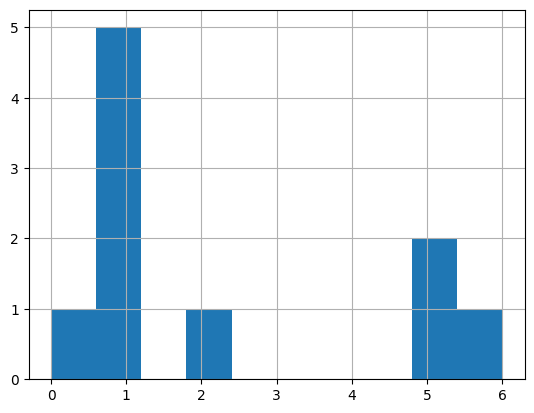

In [226]:
s.hist()

### String manipulation
https://pandas.pydata.org/docs/user_guide/text.html#text-string-methods

In [228]:
s = pd.Series(['A', 'B', 'C', 'Aaba', 'Baca', np.nan, 'CABA', 'dog', 'cat'])
s.str.lower()

0       a
1       b
2       c
3    aaba
4    baca
5     NaN
6    caba
7     dog
8     cat
dtype: str

In [229]:
s.str.replace('A','r')

0       r
1       B
2       C
3    raba
4    Baca
5     NaN
6    CrBr
7     dog
8     cat
dtype: str

### Appending data

https://pandas.pydata.org/docs/user_guide/merging.html

In [230]:
df = pd.DataFrame(np.random.randn(10, 4), columns=['a', 'b', 'c', 'd'])
df

,a,b,c,d
0,0.429254,-0.272588,-0.456226,0.387847
1,2.314607,-0.354416,0.738877,-0.347224
2,0.487655,-0.887794,-0.431561,-1.187729
3,1.169396,-1.499769,-2.031835,1.102594
4,-0.959696,0.011708,-2.022949,0.725800
5,-0.885256,-2.108928,0.665986,0.085224
6,-0.550278,0.689801,0.653845,1.511473
7,-0.113541,1.212736,-2.054747,0.907344
8,0.721944,-0.985521,0.226616,0.886189
9,0.601203,0.264429,-0.066419,1.799186


In [231]:
pieces = df[:3], df[3:7], df[7:]
pieces

(          a         b         c         d
 0  0.429254 -0.272588 -0.456226  0.387847
 1  2.314607 -0.354416  0.738877 -0.347224
 2  0.487655 -0.887794 -0.431561 -1.187729,
           a         b         c         d
 3  1.169396 -1.499769 -2.031835  1.102594
 4 -0.959696  0.011708 -2.022949  0.725800
 5 -0.885256 -2.108928  0.665986  0.085224
 6 -0.550278  0.689801  0.653845  1.511473,
           a         b         c         d
 7 -0.113541  1.212736 -2.054747  0.907344
 8  0.721944 -0.985521  0.226616  0.886189
 9  0.601203  0.264429 -0.066419  1.799186)

In [232]:
pieces[1][['a', 'c']]

,a,c
3,1.169396,-2.031835
4,-0.959696,-2.022949
5,-0.885256,0.665986
6,-0.550278,0.653845


In [233]:
pd.concat(pieces)

,a,b,c,d
0,0.429254,-0.272588,-0.456226,0.387847
1,2.314607,-0.354416,0.738877,-0.347224
2,0.487655,-0.887794,-0.431561,-1.187729
3,1.169396,-1.499769,-2.031835,1.102594
4,-0.959696,0.011708,-2.022949,0.725800
5,-0.885256,-2.108928,0.665986,0.085224
6,-0.550278,0.689801,0.653845,1.511473
7,-0.113541,1.212736,-2.054747,0.907344
8,0.721944,-0.985521,0.226616,0.886189
9,0.601203,0.264429,-0.066419,1.799186


In [234]:
pd.concat((pieces[0], pieces[-1]))

,a,b,c,d
0,0.429254,-0.272588,-0.456226,0.387847
1,2.314607,-0.354416,0.738877,-0.347224
2,0.487655,-0.887794,-0.431561,-1.187729
7,-0.113541,1.212736,-2.054747,0.907344
8,0.721944,-0.985521,0.226616,0.886189
9,0.601203,0.264429,-0.066419,1.799186


### Joining
https://pandas.pydata.org/docs/user_guide/merging.html#merging-join

In [235]:
left = pd.DataFrame({'key': ['foo', 'foo'], 'lval': [1, 2]})
right = pd.DataFrame({'key': ['foo', 'foo'], 'rval': [4, 5]})
left, right

(   key  lval
 0  foo     1
 1  foo     2,
    key  rval
 0  foo     4
 1  foo     5)

In [236]:
pd.merge(left, right)

,key,lval,rval
0,foo,1,4
1,foo,1,5
2,foo,2,4
3,foo,2,5


In [237]:
pd.merge(left, right, on='key')

,key,lval,rval
0,foo,1,4
1,foo,1,5
2,foo,2,4
3,foo,2,5


In [238]:
left = pd.DataFrame({'key': ['foo', 'bar'], 'lval': [1, 2]})
right = pd.DataFrame({'key': ['foo', 'bar'], 'rval': [4, 5]})
left, right

(   key  lval
 0  foo     1
 1  bar     2,
    key  rval
 0  foo     4
 1  bar     5)

In [239]:
pd.merge(left, right, on='key')

,key,lval,rval
0,foo,1,4
1,bar,2,5


In [240]:
left = pd.DataFrame({'key': ['foo', 'bar', 'foo'], 'lval': [1, 2, 4]})
right = pd.DataFrame({'key': ['foo', 'bar'], 'rval': [4, 5]})
left, right

(   key  lval
 0  foo     1
 1  bar     2
 2  foo     4,
    key  rval
 0  foo     4
 1  bar     5)

In [241]:
pd.merge(left, right, on='key')

,key,lval,rval
0,foo,1,4
1,bar,2,5
2,foo,4,4


### Grouping
https://pandas.pydata.org/docs/user_guide/groupby.html

In [242]:
df = pd.DataFrame({
    'a': ['foo', 'bar', 'foo', 'bar', 'foo', 'bar', 'foo', 'foo'],
    'b': ['one', 'one', 'two', 'three', 'two', 'two', 'one', 'three'],
    'c': np.random.randn(8),
    'd': np.random.randn(8),
    })
df

,a,b,c,d
0,foo,one,0.452366,-0.842859
1,bar,one,-1.913310,1.510643
2,foo,two,-0.319219,-1.275060
3,bar,three,1.144809,0.980156
4,foo,two,-0.267814,1.342628
5,bar,two,-0.291834,-0.551346
6,foo,one,0.103981,0.787239
7,foo,three,-1.012998,0.334056


In [243]:
df.groupby('a')[['c', 'd']].sum()

,c,d
a,,
bar,-1.060335,1.939454
foo,-1.043684,0.346003


In [244]:
df.groupby(['b', 'a']).sum()

c         d
b     a                      
one   bar -1.913310  1.510643
      foo  0.556347 -0.055620
three bar  1.144809  0.980156
      foo -1.012998  0.334056
two   bar -0.291834 -0.551346
      foo -0.587033  0.067568

### Reshaping
https://pandas.pydata.org/docs/user_guide/advanced.html
https://pandas.pydata.org/docs/user_guide/reshaping.html

In [245]:
tuples = list(zip(*[['bar', 'bar', 'baz', 'baz', 'foo', 'foo', 'qux', 'qux'],
                    ['one', 'two', 'one', 'two', 'one', 'two', 'one', 'two']]))
tuples

[('bar', 'one'),
 ('bar', 'two'),
 ('baz', 'one'),
 ('baz', 'two'),
 ('foo', 'one'),
 ('foo', 'two'),
 ('qux', 'one'),
 ('qux', 'two')]

In [246]:
index = pd.MultiIndex.from_tuples(tuples, names=["first", "second"])
index

MultiIndex([('bar', 'one'),
            ('bar', 'two'),
            ('baz', 'one'),
            ('baz', 'two'),
            ('foo', 'one'),
            ('foo', 'two'),
            ('qux', 'one'),
            ('qux', 'two')],
           names=['first', 'second'])

In [247]:
df = pd.DataFrame(np.random.randn(8, 2), index=index, columns=["A", "B"])
df

A         B
first second                    
bar   one     0.282111 -0.505830
      two     0.569282 -1.336259
baz   one    -0.177757 -0.091804
      two    -2.279662  0.505747
foo   one    -0.364949  0.805412
      two    -1.260779 -0.482870
qux   one     0.089102  0.415530
      two     1.486063  0.890819

In [248]:
df2 = df[:4]
stacked = df2.stack()
stacked

first  second   
bar    one     A    0.282111
               B   -0.505830
       two     A    0.569282
               B   -1.336259
baz    one     A   -0.177757
               B   -0.091804
       two     A   -2.279662
               B    0.505747
dtype: float64

In [249]:
stacked.index

MultiIndex([('bar', 'one', 'A'),
            ('bar', 'one', 'B'),
            ('bar', 'two', 'A'),
            ('bar', 'two', 'B'),
            ('baz', 'one', 'A'),
            ('baz', 'one', 'B'),
            ('baz', 'two', 'A'),
            ('baz', 'two', 'B')],
           names=['first', 'second', None])

In [250]:
stacked.unstack()

A         B
first second                    
bar   one     0.282111 -0.505830
      two     0.569282 -1.336259
baz   one    -0.177757 -0.091804
      two    -2.279662  0.505747

In [251]:
stacked.unstack(1)

second        one       two
first                      
bar   A  0.282111  0.569282
      B -0.505830 -1.336259
baz   A -0.177757 -2.279662
      B -0.091804  0.505747

In [252]:
stacked.unstack().unstack()

A                   B          
second       one       two       one       two
first                                         
bar     0.282111  0.569282 -0.505830 -1.336259
baz    -0.177757 -2.279662 -0.091804  0.505747

### Pivot tables
https://pandas.pydata.org/docs/user_guide/reshaping.html#reshaping-pivot

In [253]:
df = pd.DataFrame({
                'class': ['one', 'one', 'two', 'three'] * 3,
                'cat': ['A', 'B', 'C'] * 4,
                'type': ['foo', 'foo', 'foo', 'bar', 'bar', 'bar'] * 2,
                'value1': np.random.randn(12),
                'value2': np.random.randn(12)
                })
df

,class,cat,type,value1,value2
0,one,A,foo,0.668838,1.722835
1,one,B,foo,0.382124,2.273748
2,two,C,foo,-0.425411,1.117036
3,three,A,bar,-1.385889,-0.300562
4,one,B,bar,-0.996439,1.748105
5,one,C,bar,0.760710,-0.242019
6,two,A,foo,-0.108758,0.610032
7,three,B,foo,-0.397476,0.245736
8,one,C,foo,-0.758564,2.583828
9,one,A,bar,2.316867,-0.367761


In [254]:
pd.pivot_table(df, values='value1', index=['class', 'cat'], columns='type')

type            bar       foo
class cat                    
one   A    2.316867  0.668838
      B   -0.996439  0.382124
      C    0.760710 -0.758564
three A   -1.385889       NaN
      B         NaN -0.397476
      C    1.268789       NaN
two   A         NaN -0.108758
      B    0.946622       NaN
      C         NaN -0.425411

In [255]:
pd.pivot_table(df, values=['value1', 'value2'], index=['class', 'cat'], columns='type')

value1              value2          
type            bar       foo       bar       foo
class cat                                        
one   A    2.316867  0.668838 -0.367761  1.722835
      B   -0.996439  0.382124  1.748105  2.273748
      C    0.760710 -0.758564 -0.242019  2.583828
three A   -1.385889       NaN -0.300562       NaN
      B         NaN -0.397476       NaN  0.245736
      C    1.268789       NaN -0.287364       NaN
two   A         NaN -0.108758       NaN  0.610032
      B    0.946622       NaN -0.094770       NaN
      C         NaN -0.425411       NaN  1.117036

### Time series
https://pandas.pydata.org/docs/user_guide/timeseries.html<br>
https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html#time-series

In [256]:
dr = pd.date_range('20210101', periods=100, freq='s')
dr

DatetimeIndex(['2021-01-01 00:00:00', '2021-01-01 00:00:01',
               '2021-01-01 00:00:02', '2021-01-01 00:00:03',
               '2021-01-01 00:00:04', '2021-01-01 00:00:05',
               '2021-01-01 00:00:06', '2021-01-01 00:00:07',
               '2021-01-01 00:00:08', '2021-01-01 00:00:09',
               '2021-01-01 00:00:10', '2021-01-01 00:00:11',
               '2021-01-01 00:00:12', '2021-01-01 00:00:13',
               '2021-01-01 00:00:14', '2021-01-01 00:00:15',
               '2021-01-01 00:00:16', '2021-01-01 00:00:17',
               '2021-01-01 00:00:18', '2021-01-01 00:00:19',
               '2021-01-01 00:00:20', '2021-01-01 00:00:21',
               '2021-01-01 00:00:22', '2021-01-01 00:00:23',
               '2021-01-01 00:00:24', '2021-01-01 00:00:25',
               '2021-01-01 00:00:26', '2021-01-01 00:00:27',
               '2021-01-01 00:00:28', '2021-01-01 00:00:29',
               '2021-01-01 00:00:30', '2021-01-01 00:00:31',
               '2021-01-

In [257]:
ts = pd.Series(np.random.randint(0, 100, len(dr)), index=dr)
ts

2021-01-01 00:00:00    14
2021-01-01 00:00:01    57
2021-01-01 00:00:02    54
2021-01-01 00:00:03     5
2021-01-01 00:00:04     3
                       ..
2021-01-01 00:01:35     4
2021-01-01 00:01:36    28
2021-01-01 00:01:37    63
2021-01-01 00:01:38    16
2021-01-01 00:01:39    10
Freq: s, Length: 100, dtype: int64

In [258]:
# add 5 business days to dr
# there are several offsets available in pandas, e.g. for month end, quarter end, year end, etc.
dr + pd.offsets.BusinessDay(5)

DatetimeIndex(['2021-01-08 00:00:00', '2021-01-08 00:00:01',
               '2021-01-08 00:00:02', '2021-01-08 00:00:03',
               '2021-01-08 00:00:04', '2021-01-08 00:00:05',
               '2021-01-08 00:00:06', '2021-01-08 00:00:07',
               '2021-01-08 00:00:08', '2021-01-08 00:00:09',
               '2021-01-08 00:00:10', '2021-01-08 00:00:11',
               '2021-01-08 00:00:12', '2021-01-08 00:00:13',
               '2021-01-08 00:00:14', '2021-01-08 00:00:15',
               '2021-01-08 00:00:16', '2021-01-08 00:00:17',
               '2021-01-08 00:00:18', '2021-01-08 00:00:19',
               '2021-01-08 00:00:20', '2021-01-08 00:00:21',
               '2021-01-08 00:00:22', '2021-01-08 00:00:23',
               '2021-01-08 00:00:24', '2021-01-08 00:00:25',
               '2021-01-08 00:00:26', '2021-01-08 00:00:27',
               '2021-01-08 00:00:28', '2021-01-08 00:00:29',
               '2021-01-08 00:00:30', '2021-01-08 00:00:31',
               '2021-01-

In [259]:
ts.resample('1min').sum()

2021-01-01 00:00:00    3331
2021-01-01 00:01:00    1828
Freq: min, dtype: int64

In [260]:
dr = pd.date_range('3.6.2020 00:00', periods=5, freq='D')
dr

DatetimeIndex(['2020-03-06', '2020-03-07', '2020-03-08', '2020-03-09',
               '2020-03-10'],
              dtype='datetime64[us]', freq='D')

In [261]:
ts = pd.Series(np.random.randn(len(dr)), index=dr)
ts

2020-03-06   -0.408832
2020-03-07   -0.471981
2020-03-08   -0.939797
2020-03-09    1.049057
2020-03-10   -0.619507
Freq: D, dtype: float64

In [262]:
ts_utc = ts.tz_localize('UTC')
ts_utc

2020-03-06 00:00:00+00:00   -0.408832
2020-03-07 00:00:00+00:00   -0.471981
2020-03-08 00:00:00+00:00   -0.939797
2020-03-09 00:00:00+00:00    1.049057
2020-03-10 00:00:00+00:00   -0.619507
Freq: D, dtype: float64

In [263]:
ti = pd.date_range('1.1.2020', periods=12, freq='ME')
ti

DatetimeIndex(['2020-01-31', '2020-02-29', '2020-03-31', '2020-04-30',
               '2020-05-31', '2020-06-30', '2020-07-31', '2020-08-31',
               '2020-09-30', '2020-10-31', '2020-11-30', '2020-12-31'],
              dtype='datetime64[us]', freq='ME')

In [264]:
ts = pd.Series(np.random.randn(len(ti)), index=ti)
ts

2020-01-31    0.771936
2020-02-29    0.124533
2020-03-31   -0.057078
2020-04-30   -0.089622
2020-05-31   -0.746603
2020-06-30    0.376425
2020-07-31   -0.018694
2020-08-31   -0.670850
2020-09-30   -0.237167
2020-10-31    0.550188
2020-11-30   -0.386532
2020-12-31   -0.820863
Freq: ME, dtype: float64

In [265]:
ts.to_period()

2020-01    0.771936
2020-02    0.124533
2020-03   -0.057078
2020-04   -0.089622
2020-05   -0.746603
2020-06    0.376425
2020-07   -0.018694
2020-08   -0.670850
2020-09   -0.237167
2020-10    0.550188
2020-11   -0.386532
2020-12   -0.820863
Freq: M, dtype: float64

In [266]:
ts.to_period().to_timestamp()

2020-01-01    0.771936
2020-02-01    0.124533
2020-03-01   -0.057078
2020-04-01   -0.089622
2020-05-01   -0.746603
2020-06-01    0.376425
2020-07-01   -0.018694
2020-08-01   -0.670850
2020-09-01   -0.237167
2020-10-01    0.550188
2020-11-01   -0.386532
2020-12-01   -0.820863
Freq: MS, dtype: float64

In [267]:
# resample time index
ti = pd.period_range('2019Q1', '2020Q4', freq='Q-SEP')
ti

PeriodIndex(['2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1', '2020Q2',
             '2020Q3', '2020Q4'],
            dtype='period[Q-SEP]')

In [268]:
ts = pd.Series(np.random.randn(len(ti)), ti)
# create beginning of month, then add hour + 9
ts.index = (ti.asfreq('M', 'e') + 1).asfreq('h', 's') + 9
ts

2019-01-01 09:00    1.503159
2019-04-01 09:00   -0.010532
2019-07-01 09:00   -0.049192
2019-10-01 09:00    0.256366
2020-01-01 09:00    1.265173
2020-04-01 09:00    1.804266
2020-07-01 09:00   -1.777972
2020-10-01 09:00    1.050794
Freq: h, dtype: float64

### Categorical data
https://pandas.pydata.org/docs/user_guide/categorical.html

In [269]:
df = pd.DataFrame({"id": [1, 2, 3, 4, 5, 6],
                   "raw_grade": ["a", "b", "b", "a", "a", "e"]})
df

,id,raw_grade
0,1,a
1,2,b
2,3,b
3,4,a
4,5,a
5,6,e


In [270]:
df.dtypes

id           int64
raw_grade      str
dtype: object

In [271]:
df['grade'] = df.raw_grade.astype('category')
# if we want to convert inline
# df.raw_grade = df.raw_grade.astype('category')

In [272]:
df.dtypes

id              int64
raw_grade         str
grade        category
dtype: object

In [273]:
new_categories = ['very good', 'good', 'fail']
df.grade = df.grade.cat.rename_categories(new_categories)
df.grade

0    very good
1         good
2         good
3    very good
4    very good
5         fail
Name: grade, dtype: category
Categories (3, str): ['very good', 'good', 'fail']

In [274]:
df.groupby('grade').size()

grade
very good    3
good         2
fail         1
dtype: int64

In [275]:
df.sort_values(by='grade', ascending=False)

,id,raw_grade,grade
5,6,e,fail
1,2,b,good
2,3,b,good
0,1,a,very good
3,4,a,very good
4,5,a,very good


### Plotting (visualisation)
https://pandas.pydata.org/docs/user_guide/visualization.html

In [ ]:
days = 1000
ts = pd.Series(np.random.randn(days), index=pd.date_range("1/1/2018", periods=days))
ts.cumsum().plot()

In [ ]:
df = pd.DataFrame(np.random.randn(days, 4), index=ts.index, columns=list("abcd"))
df = df.cumsum()
df.plot()

In [ ]:
df3 = pd.DataFrame(np.random.randn(days, 2), columns=['b', 'c']).cumsum()
df3['x'] = pd.Series(list(range(len(df))))
df3.plot(x='x', y='b')

In [ ]:
df3.plot(x='x', y=['b', 'c'])

### Reading / writing data

In [ ]:
df.to_csv('foo.txt')

In [ ]:
pd.read_csv('foo.txt').head()

In [ ]:
excel_installed = True
try:
    df.to_excel('foo.xlsx', sheet_name='Foo')
except:
    excel_installed = False
    !pip install openpyxl
    df.to_excel('foo.xlsx', sheet_name='Foo')


In [ ]:
pd.read_excel('foo.xlsx', sheet_name='Foo', index_col=None, na_values=['NA'])

In [ ]:
if not excel_installed:
    !pip uninstall -y openpyxl et-xmlfile

In [ ]:
!pip list